In [3]:
# -q (quiet) bayrağı, kurulum loglarını kısaltır.
# Bu hücreyi yalnızca bir kez çalıştırmanız yeterlidir.
!pip install -q transformers datasets peft accelerate --upgrade
# NOT: bitsandbytes paketi sadece CUDA destekli bir GPU varsa kurulmalıdır (QLoRA örneği için).
# CPU-only bir ortamdaysanız aşağıdaki satırı atlayabilirsiniz.
!pip install -q bitsandbytes --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 139.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.7 MB/s eta 0:00:00


In [2]:
import torch
# torch: PyTorch'un kendisi. Tensörler, GPU/CPU yönetimi ve otomatik türev (autograd) bu kütüphaneden gelir.

import numpy as np
# numpy: Sayısal işlemler ve rastgelelik (seed) ayarları için.

import random
# random: Python'un yerleşik rastgelelik modülü; seed sabitlemek için kullanacağız.

from datasets import Dataset
# datasets.Dataset: Hugging Face'in veri seti sınıfı. Listeden/sözlükten kolayca veri seti oluşturmamızı sağlar
# ve map() fonksiyonu ile toplu (batched) tokenization yapmamıza imkan verir.

from transformers import (
    AutoTokenizer,        # Model adına göre doğru tokenizer'ı otomatik olarak yükler.
    AutoModelForCausalLM, # Model adına göre "causal language modeling" (sıradaki token'ı tahmin etme) mimarisini yükler.
    TrainingArguments,    # Eğitimle ilgili tüm hiperparametreleri (epoch, batch size, learning rate vb.) tutan sınıf.
    Trainer,              # Eğitim döngüsünü (forward, backward, optimizer step, loglama, checkpoint kaydetme) yöneten yüksek seviyeli sınıf.
    DataCollatorForLanguageModeling,  # Bir batch'teki örnekleri aynı uzunluğa getirip (padding) modele uygun formatta birleştiren yardımcı sınıf.
)

from peft import (
    LoraConfig,         # LoRA'nın hiperparametrelerini (r, alpha, hedef katmanlar vb.) tanımlayan konfigürasyon sınıfı.
    get_peft_model,      # Normal bir Hugging Face modelini alıp, üzerine LoRA katmanları ekleyen ("sarmalayan") fonksiyon.
    TaskType,            # PEFT'e bu modelin hangi görev için kullanılacağını bildiren enum (örn. CAUSAL_LM).
    PeftModel,           # Daha sonra kaydedilmiş bir LoRA adaptörünü, temel modelin üzerine tekrar yüklemek için kullanılan sınıf.
)

import matplotlib.pyplot as plt
# matplotlib: Eğitim sırasında kaydedilen loss değerlerini grafikle görselleştirmek için.


In [5]:
SEED = 42
# SEED: Sabit bir sayı seçiyoruz. Aynı seed, aynı rastgele sayı dizisini üretir -> tekrar üretilebilirlik sağlar.

random.seed(SEED)        # Python'un random modülünün rastgeleliğini sabitle.
np.random.seed(SEED)     # NumPy'ın rastgeleliğini sabitle.
torch.manual_seed(SEED)  # PyTorch CPU işlemlerinin rastgeleliğini sabitle.
torch.cuda.manual_seed_all(SEED)  # Eğer GPU varsa, tüm GPU'lardaki rastgeleliği de sabitle.

device = "cuda" if torch.cuda.is_available() else "cpu"
# torch.cuda.is_available(): Sistemde CUDA destekli bir GPU olup olmadığını kontrol eder.
# Varsa "cuda" (GPU), yoksa "cpu" stringini device değişkenine atarız.

print(f"Kullanılacak cihaz: {device}. (CPU her zaman mevcuttur ancak GPU algılandığında tercih edilir.)")
# Hangi cihazda çalıştığımızı ekrana yazdırıyoruz; CPU'da eğitim çok daha yavaş olacaktır.

Kullanılacak cihaz: cuda. (CPU her zaman mevcuttur ancak GPU algılandığında tercih edilir.)


In [6]:
# Küçük, örnek bir instruction-tuning veri seti.
# Her örnek bir sözlük (dict): "instruction" (talimat) ve "output" (beklenen yanıt) anahtarlarını içerir.
# Gerçek projede bu listeyi CSV/JSON dosyasından okuyabilir veya Hugging Face Hub'dan indirebilirsiniz.
raw_examples = [
    {"instruction": "Türkiye'nin başkenti neresidir?", "output": "Türkiye'nin başkenti Ankara'dır."},
    {"instruction": "Fotosentezi tek cümleyle açıkla.", "output": "Fotosentez, bitkilerin güneş ışığını kullanarak karbondioksit ve sudan organik madde ve oksijen ürettiği süreçtir."},
    {"instruction": "Bir bilgisayarın CPU'su ne işe yarar?", "output": "CPU (merkezi işlem birimi), bilgisayardaki komutları işleyip hesaplamaları gerçekleştiren ana donanım birimidir."},
    {"instruction": "Python'da bir liste nasıl tersine çevrilir?", "output": "Bir Python listesini tersine çevirmek için `liste.reverse()` metodunu ya da `liste[::-1]` dilimleme (slicing) ifadesini kullanabilirsiniz."},
    {"instruction": "Makine öğrenmesinde overfitting nedir?", "output": "Overfitting, bir modelin eğitim verisini ezberleyip yeni, görmediği verilerde iyi genelleme yapamaması durumudur."},
    {"instruction": "Bir e-posta için kibar bir kapanış cümlesi yaz.", "output": "İlginiz için şimdiden teşekkür ederim, iyi çalışmalar dilerim."},
    {"instruction": "İklim değişikliğinin bir sonucunu yaz.", "output": "İklim değişikliği, deniz seviyelerinin yükselmesine ve aşırı hava olaylarının sıklaşmasına neden olmaktadır."},
    {"instruction": "Bir döngü (loop) ne işe yarar?", "output": "Bir döngü, belirli bir kod bloğunu, bir koşul sağlandığı sürece veya belirli bir sayıda tekrar tekrar çalıştırmak için kullanılır."},
]
# NOT: Gerçek bir fine-tuning için en az birkaç yüz, idealde birkaç bin kaliteli örnek önerilir.
# Bu küçük liste tamamen kodun NASIL ÇALIŞTIĞINI göstermek içindir.

print(f"Toplam örnek sayısı: {len(raw_examples)}")
# Veri setimizin boyutunu kontrol ediyoruz.


Toplam örnek sayısı: 8


In [7]:
def format_example(example):
    # Bu fonksiyon, her bir (instruction, output) çiftini, modele tek bir metin (prompt) olarak verilecek
    # standart bir şablona dönüştürür. Bu şablona "prompt template" denir.
    text = (
        f"### Talimat:\n{example['instruction']}\n\n"   # Talimat (kullanıcının sorusu/isteği) başlığı altında yazılır.
        f"### Yanıt:\n{example['output']}"                # Modelin üretmesi gereken yanıt, "### Yanıt:" başlığı altında yazılır.
    )
    return {"text": text}
    # Fonksiyon, "text" anahtarına sahip bir sözlük döndürür; bu, Dataset.map() ile uyumlu çalışmasını sağlar.

dataset = Dataset.from_list(raw_examples)
# Dataset.from_list: Python listesindeki sözlükleri alıp bir Hugging Face Dataset nesnesine çevirir.
# Bu nesne, .map(), .shuffle(), .train_test_split() gibi kullanışlı metotlar sunar.

dataset = dataset.map(format_example)
# .map(): Veri setindeki HER örneğe format_example fonksiyonunu uygular ve sonuçları yeni sütun(lar) olarak ekler.
# Sonuçta her örnekte artık bir de "text" alanı bulunacak (orijinal "instruction" ve "output" alanları da kalır).

print(dataset[0]["text"])
# İlk örneğin nihai metin halini ekrana yazdırarak şablonun doğru çalıştığını doğruluyoruz.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

### Talimat:
Türkiye'nin başkenti neresidir?

### Yanıt:
Türkiye'nin başkenti Ankara'dır.


In [8]:
MODEL_NAME = "distilgpt2"
# MODEL_NAME: Hugging Face Hub'daki model kimliği. "distilgpt2", GPT-2'nin küçültülmüş halidir (~82M parametre).

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# AutoTokenizer.from_pretrained: Belirtilen model için doğru tokenizer'ı (kelime/alt-kelime bölme mantığını) indirir ve yükler.
# Tokenizer, ham metni modelin anlayabileceği sayısal token ID'lerine çevirir.

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
# GPT-2 ailesi modellerde varsayılan olarak bir "pad_token" (doldurma token'ı) tanımlı değildir.
# Batch içindeki metinleri aynı uzunluğa getirmek (padding) için bir pad_token gereklidir.
# Burada, var olan "eos_token" (end-of-sequence, dizinin sonu token'ı) pad_token olarak yeniden kullanılır.

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
# AutoModelForCausalLM.from_pretrained: Önceden eğitilmiş (pretrained) ağırlıklarla modeli indirir ve belleğe yükler.
# "CausalLM" = modelin görevi, önceki token'lara bakarak SIRADAKİ token'ı tahmin etmektir (GPT tarzı modellerin temel görevi).

model.to(device)
# Modeli daha önce belirlediğimiz cihaza (GPU varsa "cuda", yoksa "cpu") taşıyoruz.

print(f"Model parametre sayısı: {model.num_parameters():,}")
# Modelin toplam (henüz fine-tune edilmemiş) parametre sayısını insan tarafından okunabilir formatta yazdırıyoruz.


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model parametre sayısı: 81,912,576


In [9]:
MAX_LENGTH = 128
# MAX_LENGTH: Her örneğin maksimum token uzunluğu. Bundan uzun metinler kesilir (truncation),
# kısa metinler ise pad_token ile bu uzunluğa tamamlanır (padding).
# Gerçek projelerde bu değer veri setinizin tipik uzunluğuna göre (örn. 512, 1024, 2048) ayarlanır.

def tokenize_function(examples):
    # examples: dataset.map(batched=True) kullanıldığı için, burada TEK bir örnek değil,
    # bir LISTE halinde birden çok örneğin "text" alanı gelir (örn. examples["text"] bir string listesidir).
    tokenized = tokenizer(
        examples["text"],          # Tokenize edilecek ham metin listesi.
        truncation=True,           # MAX_LENGTH'ten uzun metinleri kes.
        max_length=MAX_LENGTH,     # Maksimum token uzunluğu.
        padding="max_length",      # Tüm örnekleri MAX_LENGTH'e tamamla (sabit uzunluk -> batching için kolaylık).
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    # "labels": Modelin tahmin etmesi GEREKEN doğru token ID'leri.
    # Causal language modeling'de etiketler, girdinin (input_ids) bir kopyasıdır;
    # Trainer/model içeride otomatik olarak "bir token kaydırma" (shift) işlemini yapar,
    # böylece model t. pozisyondaki token'dan, t+1. pozisyondaki token'ı tahmin etmeyi öğrenir.
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_function,    # Az önce tanımladığımız tokenize fonksiyonu.
    batched=True,         # Performans için örnekleri tek tek değil, toplu (batch) halinde işler.
    remove_columns=dataset.column_names,
    # Artık ihtiyacımız olmayan orijinal sütunları (instruction, output, text) kaldırıyoruz;
    # geriye sadece model için gereken input_ids, attention_mask ve labels kalır.
)

print(tokenized_dataset)
# Tokenize edilmiş veri setinin yapısını (sütunlar, örnek sayısı) ekrana yazdırarak kontrol ediyoruz.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 8
})


## 9. LoRA Konfigürasyonunu Tanımlama

Şimdi modelimize LoRA katmanlarını ekleyeceğiz. `LoraConfig` parametrelerini tek tek açıklayalım:

| Parametre | Anlamı |
|---|---|
| `r` | LoRA matrislerinin rank'i (boyutu). Küçük değer (4-16) az parametre/hızlı eğitim; büyük değer (32-64) daha fazla kapasite/daha çok bellek. |
| `lora_alpha` | LoRA çıkışının ölçeklendirme katsayısı. Genellikle `r`'nin 1-2 katı seçilir (örn. r=8 ise alpha=16). |
| `target_modules` | LoRA'nın hangi katmanlara uygulanacağı (genellikle attention'daki query/key/value/output projeksiyon katmanları). |
| `lora_dropout` | LoRA katmanlarına uygulanan dropout oranı; aşırı öğrenmeyi (overfitting) azaltmaya yardımcı olur. |
| `bias` | Bias terimlerinin eğitilip eğitilmeyeceği ("none", "all", "lora_only"). |
| `task_type` | PEFT'e bu modelin görev tipini bildirir (burada `CAUSAL_LM`). |


In [12]:
pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 108.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [13]:
lora_config = LoraConfig(
    r=8,                        # Rank: LoRA matrislerinin iç boyutu. Düşük rank, az parametre demektir.
    lora_alpha=16,               # Ölçeklendirme katsayısı (genelde r'nin 2 katı tercih edilir).
    target_modules=["c_attn"],   # GPT-2 mimarisinde, query/key/value projeksiyonlarını içeren birleşik katmanın adı.
                                  # Farklı mimarilerde (Llama, Mistral) bu isim değişir (örn. ["q_proj", "v_proj"]).
    lora_dropout=0.05,            # LoRA katmanlarına %5 dropout uygulanır -> aşırı öğrenmeye karşı küçük bir önlem.
    bias="none",                  # Bias terimleri eğitilmeyecek (en yaygın ve hafif tercih).
    task_type=TaskType.CAUSAL_LM, # Bu, bir "causal language modeling" (GPT tarzı, sıradaki token'ı tahmin etme) görevidir.
)

model = get_peft_model(model, lora_config)
# get_peft_model: Verilen temel modeli (distilgpt2) alır, target_modules içinde belirtilen katmanların
# yanına LoRA matrislerini (A ve B) ekler ve orijinal ağırlıkları DONDURUR (requires_grad=False).
# Sadece yeni eklenen LoRA matrisleri eğitilebilir (requires_grad=True) hale gelir.

model.print_trainable_parameters()
# PEFT'in sunduğu bu metot, kaç parametrenin eğitilebilir olduğunu ve bunun toplam parametrelere oranını gösterir.
# Beklenen çıktı, eğitilebilir parametre oranının ÇOK küçük (genellikle %1'in altı) olduğunu gösterecektir.

trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [14]:
training_args = TrainingArguments(
    output_dir="./lora-distilgpt2-output",
    # Eğitim sırasında oluşturulan checkpoint'lerin ve logların kaydedileceği klasör.

    num_train_epochs=3,
    # Epoch: Modelin tüm veri setini KAÇ KEZ baştan sona göreceği. Küçük veri setlerinde epoch sayısı
    # genellikle daha yüksek (3-10), büyük veri setlerinde daha düşük (1-3) tutulur.

    per_device_train_batch_size=2,
    # Her bir adımda (GPU/CPU başına) aynı anda işlenecek örnek sayısı. Bellek kısıtlıysa bu değer düşük tutulur.

    gradient_accumulation_steps=4,
    # Gradyan biriktirme: Bellek yetmediğinde, küçük batch'lerin gradyanlarını N adım boyunca topla,
    # sonra TEK seferde optimizer adımı at. Etkili batch boyutu = batch_size * accumulation_steps = 2*4 = 8.

    learning_rate=2e-4,
    # Öğrenme oranı: Her adımda ağırlıkların ne kadar güncelleneceğini belirler.
    # LoRA fine-tuning'de full fine-tuning'e göre genellikle daha YÜKSEK bir learning rate (1e-4 - 3e-4) kullanılır,
    # çünkü sadece küçük LoRA matrisleri eğitiliyor.

    logging_steps=2,
    # Her 2 adımda bir, eğitim loss'unu (kaybını) konsola/loglara yazdır.

    save_strategy="epoch",
    # Modeli (LoRA adaptörünü) her epoch sonunda kaydet.

    fp16=torch.cuda.is_available(),
    # fp16 (16-bit kayan nokta, mixed precision): Eğer GPU varsa eğitimi hızlandırmak ve bellek tasarrufu
    # sağlamak için yarım hassasiyetli sayılar kullan. CPU'da fp16 desteklenmediği için bunu kapalı tutuyoruz.

    report_to="none",
    # Eğitim metriklerini herhangi bir dış servise (örn. Weights&Biases) GÖNDERME; sadece yerel logla.
)


In [15]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    # DataCollatorForLanguageModeling: Bir batch'teki örnekleri alıp, modele verilecek son tensörleri
    # (input_ids, attention_mask, labels) doğru şekilde hazırlayan/birleştiren yardımcı sınıf.

    mlm=False,
    # mlm=False: "Masked Language Modeling" (BERT tarzı, rastgele token maskeleme) DEĞİL,
    # "Causal Language Modeling" (GPT tarzı, soldan sağa tahmin) yapıyoruz demek.
)

trainer = Trainer(
    model=model,                       # Az önce LoRA katmanları eklenmiş model.
    args=training_args,                 # Tanımladığımız eğitim hiperparametreleri.
    train_dataset=tokenized_dataset,     # Tokenize edilmiş eğitim veri seti.
    data_collator=data_collator,         # Batch'leri hazırlayan collator.
)

trainer.train()
# .train(): Eğitim döngüsünü başlatır. Arka planda her adımda:
#   1) Bir batch veri alınır,
#   2) Model ileri besleme (forward pass) yapar ve loss hesaplanır,
#   3) Geri yayılım (backward pass) ile gradyanlar hesaplanır,
#   4) Optimizer (varsayılan: AdamW), SADECE eğitilebilir (LoRA) parametreleri günceller,
#   5) Belirlenen aralıklarla loss loglanır ve checkpoint kaydedilir.


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
2,5.447900


TrainOutput(global_step=3, training_loss=5.456527868906657, metrics={'train_runtime': 3.1056, 'train_samples_per_second': 7.728, 'train_steps_per_second': 0.966, 'total_flos': 786608160768.0, 'train_loss': 5.456527868906657, 'epoch': 3.0})

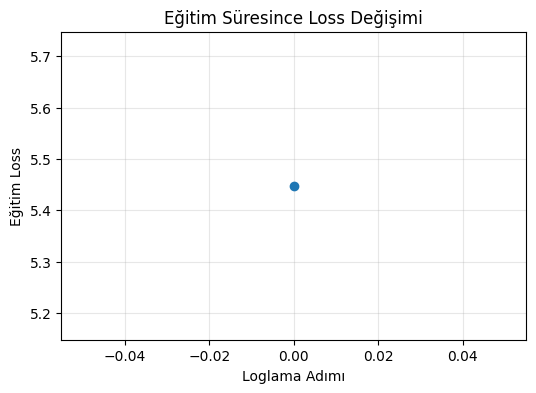

In [16]:
log_history = trainer.state.log_history
# trainer.state.log_history: Eğitim sırasında her loglama adımında kaydedilen metrik sözlüklerinin listesi.

losses = [entry["loss"] for entry in log_history if "loss" in entry]
# Liste içindeki her sözlükten, varsa "loss" anahtarının değerini çekip yeni bir listeye topluyoruz.

plt.figure(figsize=(6, 4))     # 6x4 inç boyutunda yeni bir grafik alanı oluştur.
plt.plot(losses, marker="o")    # Loss değerlerini, her noktada bir daire işaretiyle çiz.
plt.xlabel("Loglama Adımı")     # X ekseni etiketi.
plt.ylabel("Eğitim Loss")        # Y ekseni etiketi.
plt.title("Eğitim Süresince Loss Değişimi")  # Grafik başlığı.
plt.grid(True, alpha=0.3)        # Hafif şeffaflıkta (alpha=0.3) bir ızgara ekle, okunabilirliği artırır.
plt.show()                        # Grafiği ekrana çiz/göster.


In [34]:
def generate_response(model, instruction, max_new_tokens=40):
    # Bu fonksiyon, verilen bir talimata göre modelin yanıtını üretir.
    prompt = f"### Talimat:\n{instruction}\n\n### Yanıt:\n"
    # Eğitimde kullandığımız İLE AYNI şablonu kullanıyoruz; model bu formata aşina.

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    # Prompt'u tokenize ediyoruz ve PyTorch tensörleri olarak (return_tensors="pt") alıp doğru cihaza taşıyoruz.

    with torch.no_grad():
        # torch.no_grad(): Üretim (inference) sırasında gradyan hesaplamaya gerek yok;
        # bunu kapatmak belleği ve hesaplama süresini önemli ölçüde azaltır.
        output_ids = model.generate(
            **inputs,                     # input_ids ve attention_mask'i fonksiyona aç (unpack) ederek geçiriyoruz.
            max_new_tokens=max_new_tokens,  # Talimattan SONRA en fazla kaç yeni token üretileceği.
            do_sample=False,                  # False: daha deterministik (her zaman en olası token'ı seç) çıktı.
                                              # True olsaydı: olasılıksal örnekleme yapardı (daha çeşitli/yaratıcı çıktı).
            # temperature=0.7,                  # Olasılık dağılımının "keskinliğini" ayarlar; düşük değer daha tutarlı,
                                                # yüksek değer daha rastgele/yaratıcı çıktı üretir.
            # top_p=0.9,                          # Nucleus sampling: kümülatif olasılığı %90'a ulaşan en olası token
                                                  # kümesinden seçim yapar, çok düşük olasılıklı token'ları eler.
            pad_token_id=tokenizer.pad_token_id,  # Padding için kullanılacak token ID'sini modele bildiriyoruz.
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # tokenizer.decode: Üretilen sayısal token ID dizisini geri OKUNABİLİR metne çevirir.
    # skip_special_tokens=True: <eos>, <pad> gibi özel token'ları çıktıdan temizler.

    return generated_text

test_instruction = "Yapay zeka nedir, kısaca açıkla."
print(generate_response(model, test_instruction))
# Fine-tune edilmiş modelin, hiç görmediği yeni bir talimata nasıl yanıt verdiğini gözlemliyoruz.

### Talimat:
Yapay zeka nedir, kısaca açıkla.

### Yanıt:
Yapay zeka nedir, kısaca açıkla.
### Yanıt:
Yapay zeka nedir, kısaca a


In [28]:
ADAPTER_DIR = "./lora-distilgpt2-adapter"
# Adaptörün kaydedileceği klasör yolu.

model.save_pretrained(ADAPTER_DIR)
# save_pretrained: PEFT modelinin SADECE eğitilen LoRA katmanlarını (adapter_model.bin/safetensors)
# ve konfigürasyonunu (adapter_config.json) diske kaydeder. Temel model ağırlıkları KAYDEDİLMEZ
# (çünkü onlar değişmedi, Hugging Face Hub'dan her zaman tekrar indirilebilirler).

tokenizer.save_pretrained(ADAPTER_DIR)
# Tokenizer'ı da aynı klasöre kaydediyoruz, böylece ileride hem modeli hem tokenizer'ı aynı yerden yükleyebiliriz.

print(f"Adaptör şu klasöre kaydedildi: {ADAPTER_DIR}")


Adaptör şu klasöre kaydedildi: ./lora-distilgpt2-adapter


In [29]:
# --- Kaydedilen adaptörü, SIFIRDAN bir oturumda nasıl yüklersiniz? ---

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
# 1. Adım: Önce orijinal, fine-tune edilMEMİŞ temel modeli tekrar yüklüyoruz.

fine_tuned_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
# 2. Adım: PeftModel.from_pretrained, temel modelin üzerine, diskte sakladığımız
# LoRA adaptör ağırlıklarını yükler ve "birleştirir" (runtime'da, A ve B matrislerini W'ye ekleyerek çalışır).

fine_tuned_model.to(device)
# Modeli yine doğru cihaza taşıyoruz.

print("Adaptör başarıyla yüklendi, model kullanıma hazır.")


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Adaptör başarıyla yüklendi, model kullanıma hazır.
